In [16]:
import pandas as pd
import sklearn as sk
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib, os
import re

file_path = Path(r"E:\AI\Datasets\homes.csv")

df = pd.read_csv(file_path)
print(df.shape)
print(df.isnull().sum())

(9183, 7)
Area        212
Baths        62
Bedrooms     11
Location     85
Price         0
Purpose      40
Type         21
dtype: int64


In [17]:
def clean_pakistan_real_estate(df):
    df['Area'] = df['Area'].astype(str).str.replace(',', '')
    df['Area'] = df['Area'].str.extract(r'(\d+\.?\d*)').astype(float)

    def convert_price(price_str):
        price_str = str(price_str).lower().replace(',', '')

        match = re.search(r'(\d+\.?\d*)', price_str)
        if not match:
            return None
        
        val = float(match.group(1))
        
        if 'crore' in price_str:
            return val * 10_000_000
        elif 'lakh' in price_str:
            return val * 100_000
        return val

    df['Price'] = df['Price'].apply(convert_price)
  
    df['Baths'] = pd.to_numeric(df['Baths'], errors='coerce')
    df['Bedrooms'] = pd.to_numeric(df['Bedrooms'], errors='coerce')


    df_clean = df.dropna(subset=['Area', 'Baths', 'Bedrooms', 'Price'])
    
    return df_clean

df_final = clean_pakistan_real_estate(df)

print(df_final[['Area', 'Baths', 'Bedrooms', 'Price']].head())
print("\nNew Data Types:\n", df_final.dtypes)

     Area  Baths  Bedrooms        Price
0   375.0    5.0       5.0   75000000.0
1   300.0    5.0       5.0  115000000.0
2   240.0    3.0       4.0   37000000.0
3   300.0    5.0       5.0  105000000.0
4  1000.0    6.0       6.0  400000000.0

New Data Types:
 Area        float64
Baths       float64
Bedrooms    float64
Location     object
Price       float64
Purpose      object
Type         object
dtype: object


In [18]:
print(df['Area'].dtype)

float64


In [19]:
df.shape

(9183, 7)

In [20]:
df.head()

,Area,Baths,Bedrooms,Location,Price,Purpose,Type
0,375.0,5.0,5.0,"Cantt, Karachi, Sindh",75000000.0,For Sale,House
1,300.0,5.0,5.0,"DHA Defence, Karachi, Sindh",115000000.0,For Sale,House
2,240.0,3.0,4.0,"Malir, Karachi, Sindh",37000000.0,For Sale,House
3,300.0,5.0,5.0,"DHA Defence, Karachi, Sindh",105000000.0,For Sale,House
4,1000.0,6.0,6.0,"DHA Defence, Karachi, Sindh",400000000.0,For Sale,House


In [21]:
cl = ['Area', 'Bedrooms', 'Baths', 'Price']

df = df.dropna(subset=cl)

In [22]:
df.shape

(7881, 7)

In [23]:
X = df_final[['Area', 'Bedrooms', 'Baths']]

y = df_final['Price']

print(f"Features shape: {X.shape}") 
print(f"Target shape: {y.shape}") 

Features shape: (7881, 3)
Target shape: (7881,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

In [25]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_error = mean_absolute_error(y_test, y_pred_rf)
rf_score = r2_score(y_test, y_pred_rf)

print(f"Random Forest Error: {rf_error:,.2f}")
print(f"Random Forest R2 Score: {rf_score:.2f}")

Random Forest Error: 17,620,261.09
Random Forest R2 Score: 0.75


In [26]:
n_cl = ['Area', 'Bedrooms', 'Baths', 'Location']

X_encoded = pd.get_dummies(df[n_cl], columns=['Location'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [28]:
y_pred_rf = rf_model.predict(X_test)
rf_error = mean_absolute_error(y_test, y_pred_rf)
rf_score = r2_score(y_test, y_pred_rf)

print(f"Random Forest Error: {rf_error:,.2f} PKR")
print(f"Random Forest R2 Score: {rf_score:.2f}")

Random Forest Error: 13,330,384.72 PKR
Random Forest R2 Score: 0.83


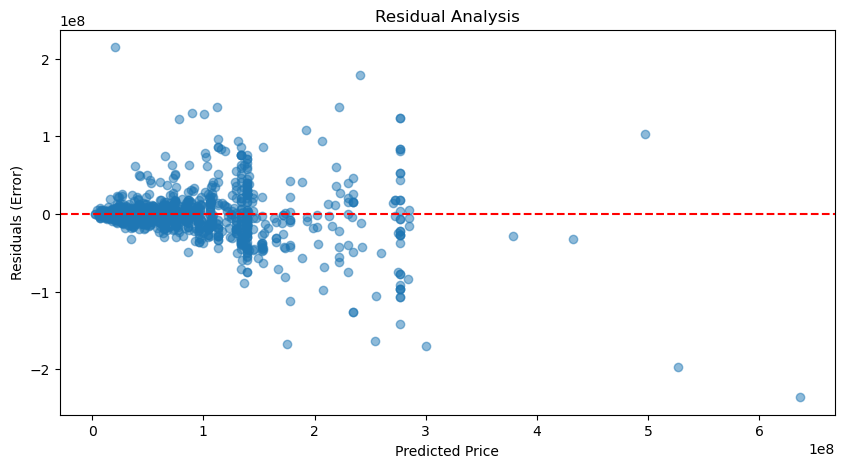

In [30]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred_rf

plt.figure(figsize=(10, 5))
plt.scatter(y_pred_rf, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals (Error)")
plt.title("Residual Analysis")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X_encoded, y, cv=5, scoring='r2')

print(f"Individual Scores: {scores}")
print(f"Average R2 Score: {scores.mean():.2f}")
print(f"Standard Deviation: {scores.std():.4f}") 

--- Model Stability Check ---
Individual Scores: [0.85057428 0.82354024 0.80458108 0.76065909 0.87573282]
Average R2 Score: 0.82
Standard Deviation: 0.0394
